# 🧠 Notebook 04 – Tiền xử lý & Huấn luyện: ĐỘT QUỴ (STROKE)
**Dataset:** `healthcare-dataset-stroke-data.csv` (5,110 mẫu)  
**Sinh viên:** Lê Trung Hiếu – 102220187

---
### ⚠️ 4 vấn đề xử lý đặc thù
| # | Vấn đề | Xử lý |
|---|--------|-------|
| 1 | BMI: 201 giá trị missing (3.9%) | Impute bằng median hoặc drop rows |
| 2 | gender: 'Other' (giá trị hiếm gặp) | Recode hoặc DROP rows |
| 3 | work_type, Residence_type: Categorical | Encode (Private→1, etc.) |
| 4 | smoking_status: unknown, never, former, smokes | Encode thứ tự tương đối |
---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 PHẦN 0: IMPORT

In [2]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns, matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import shap, joblib, os

# ==============================================================
# ✅ KHAI BÁO ĐƯỜNG DẪN ROOT ĐẾN GOOGLE DRIVE
# ==============================================================
DRIVE_PATH = '/content/drive/MyDrive/DATN_HealthRisk'
DIR_DATA = f'{DRIVE_PATH}/data'
DIR_MODELS = f'{DRIVE_PATH}/models'
DIR_RESULTS = f'{DRIVE_PATH}/results'

for d in [DIR_DATA, DIR_MODELS, DIR_RESULTS]:
    os.makedirs(d, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid'); sns.set_palette("husl")
print("✅ Import thành công và đã trỏ đường dẫn gốc vào Google Drive!")

✅ Import thành công và đã trỏ đường dẫn gốc vào Google Drive!


---
## 📋 PHẦN 1: KHÁM PHÁ & TIỀN XỬ LÝ

In [3]:
df_raw = pd.read_csv(f'{DIR_DATA}/healthcare-dataset-stroke-data.csv')

print("=" * 70)
print("📊 STROKE DATASET – 5,110 bệnh nhân")
print("=" * 70)
print(f"  Shape   : {df_raw.shape}")
print(f"  Columns : {df_raw.columns.tolist()}")
display(df_raw.head(3))

print("\n🔍 Phân tích chất lượng dữ liệu:")
print(f"1️⃣  Null values:")
null_counts = df_raw.isnull().sum()
print(f"   Total: {null_counts.sum()} missing values")
if null_counts.sum() > 0:
    for col in null_counts[null_counts > 0].index:
        print(f"   {col}: {null_counts[col]} ({null_counts[col]/len(df_raw)*100:.1f}%)")

print(f"\n2️⃣  Nhãn target (stroke):")
vc = df_raw['stroke'].value_counts().sort_index()
print(f"   Class 0 (Không): {vc[0]:,} ({vc[0]/len(df_raw)*100:.1f}%)")
print(f"   Class 1 (Có)  : {vc[1]:,} ({vc[1]/len(df_raw)*100:.1f}%)")
imb_ratio = max(vc.values) / min(vc.values)
print(f"   Imbalance ratio: {imb_ratio:.2f}:1 {'⚠️  RẤT LỆCH' if imb_ratio > 5 else '⚠️  Lệch' if imb_ratio > 2 else '✓'}")

print(f"\n3️⃣  Các cột:")
print(f"   Numeric: {df_raw.select_dtypes('number').shape[1]} cột")
print(f"   Object: {df_raw.select_dtypes('object').shape[1]} cột")
print(f"   {df_raw.select_dtypes('object').columns.tolist()}")


📊 STROKE DATASET – 5,110 bệnh nhân
  Shape   : (5110, 12)
  Columns : ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1



🔍 Phân tích chất lượng dữ liệu:
1️⃣  Null values:
   Total: 201 missing values
   bmi: 201 (3.9%)

2️⃣  Nhãn target (stroke):
   Class 0 (Không): 4,861 (95.1%)
   Class 1 (Có)  : 249 (4.9%)
   Imbalance ratio: 19.52:1 ⚠️  RẤT LỆCH

3️⃣  Các cột:
   Numeric: 7 cột
   Object: 5 cột
   ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


### 1.2 EDA – Phân phối chỉ số


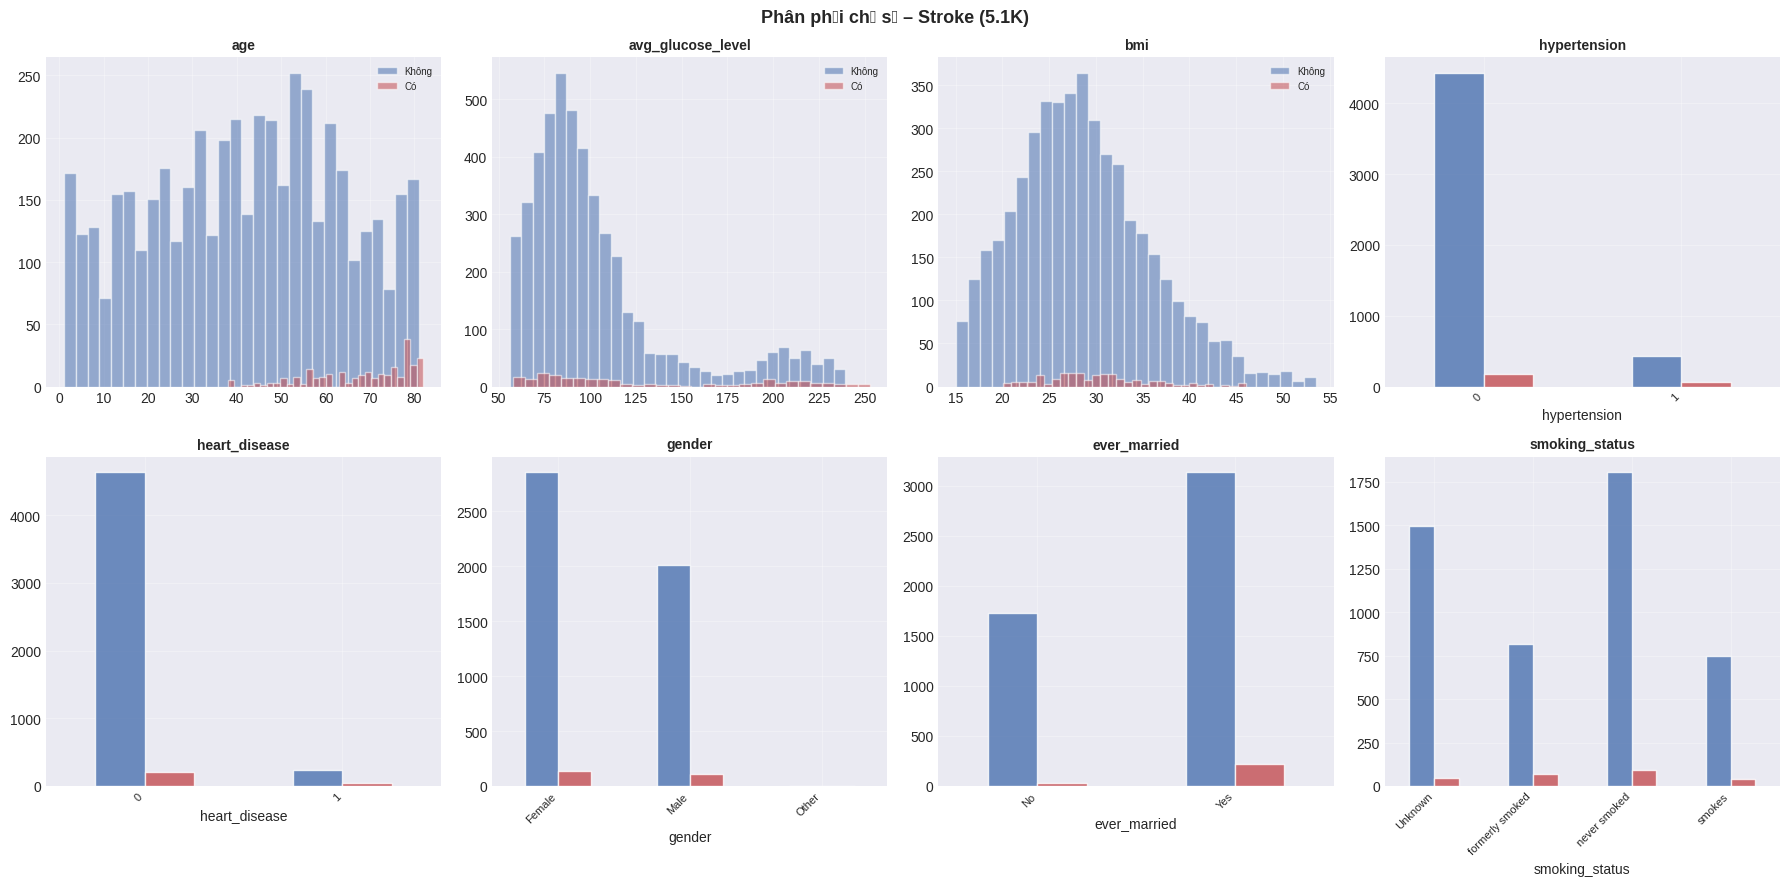

✅ EDA distributions saved


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Phân phối chỉ số – Stroke (5.1K)', fontsize=13, weight='bold')
plot_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'gender', 'ever_married', 'smoking_status']
for idx, col in enumerate(plot_cols):
    ax = axes[idx//4, idx%4]
    tmp = df_raw.copy()
    if tmp[col].dtype == 'object' or tmp[col].nunique() <= 5:
        ct = tmp.groupby([col, 'stroke']).size().unstack(fill_value=0)
        ct.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'], alpha=0.8, edgecolor='white', legend=False)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    else:
        for label, color, name in [(0, '#4C72B0', 'Không'), (1, '#C44E52', 'Có')]:
            valid = tmp[tmp['stroke']==label][col].dropna()
            valid = valid[(valid >= valid.quantile(0.01)) & (valid <= valid.quantile(0.99))]
            ax.hist(valid, bins=30, alpha=0.55, color=color, label=name, edgecolor='white')
        ax.legend(fontsize=7)
    ax.set_title(col, fontsize=10, weight='bold'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/S01_eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA distributions saved")


### 1.3 Correlation analysis


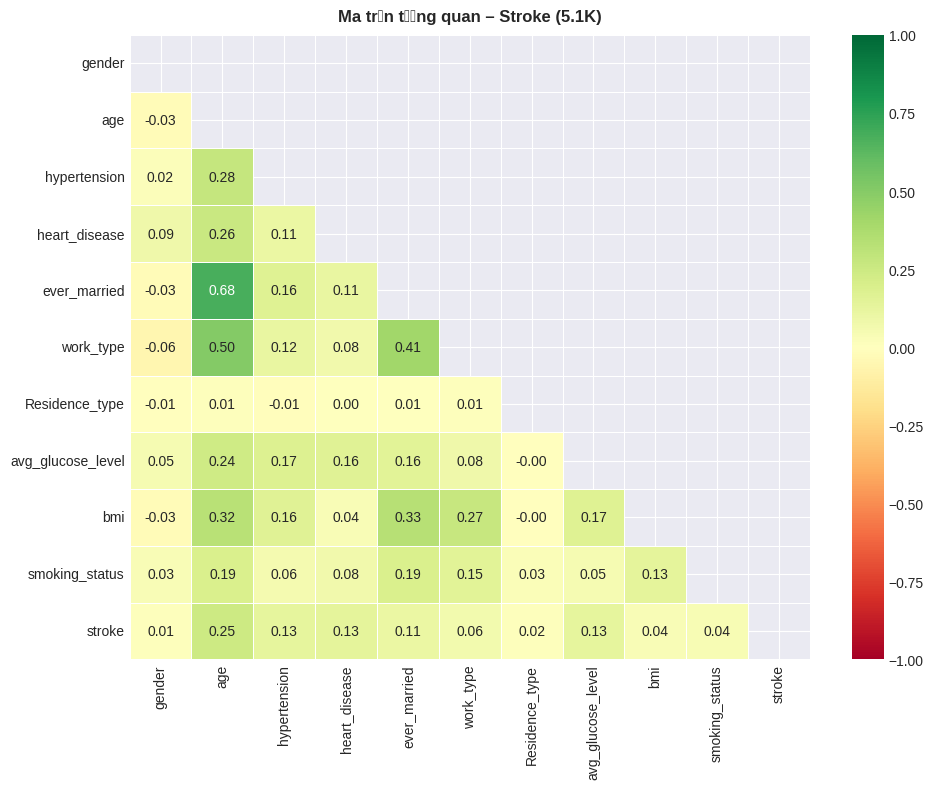

🔑 Top tương quan với nhãn stroke:
  age                  |███████                       | 0.245
  heart_disease        |████                          | 0.135
  avg_glucose_level    |███                           | 0.132
  hypertension         |███                           | 0.128
  ever_married         |███                           | 0.108
  work_type            |█                             | 0.063
  smoking_status       |█                             | 0.041
  bmi                  |█                             | 0.036


In [5]:
# Prepare data for correlation (encode categorical)
df_corr = df_raw.copy()
df_corr['gender'] = df_corr['gender'].map({'Female': 0, 'Male': 1, 'Other': 0})
df_corr['ever_married'] = df_corr['ever_married'].map({'No': 0, 'Yes': 1})
df_corr['Residence_type'] = df_corr['Residence_type'].map({'Rural': 0, 'Urban': 1})
work_map = {'Private': 1, 'Self-employed': 2, 'Govt_job': 3, 'children': 0, 'Never_worked': 0}
df_corr['work_type'] = df_corr['work_type'].map(work_map)
smoke_map = {'never smoked': 0, 'formerly smoked': 1, 'smokes': 2, 'Unknown': 0}
df_corr['smoking_status'] = df_corr['smoking_status'].map(smoke_map)
df_corr = df_corr.drop(columns=['id'])
df_corr = df_corr.fillna(df_corr.median())

plt.figure(figsize=(10, 8))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Ma trận tương quan – Stroke (5.1K)', fontsize=12, weight='bold', pad=10)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/S02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("🔑 Top tương quan với nhãn stroke:")
corr_target = corr['stroke'].drop('stroke').abs().sort_values(ascending=False)
for feat, val in corr_target.head(8).items():
    bar = '█' * int(val*30)
    print(f"  {feat:20s} |{bar:<30}| {val:.3f}")


---
## ⚙️ PHẦN 2: TIỀN XỬ LÝ (Làm sạch & Feature Engineering)


In [6]:
from sklearn.impute import KNNImputer

# Keep original work_type strings for one-hot encoding later
work_orig = df_raw['work_type'].fillna('Unknown').astype(str)

df = df_raw.drop(columns=['id']).copy()
print("🔍 TIỀN XỬ LÝ – STROKE (Chuẩn y khoa)")
print("=" * 70)

# ── BƯỚC 1: Mã hóa dữ liệu phân loại trước (không mã hóa work_type – sẽ one-hot sau impute) ─────────────────────────────────
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1, 'Other': 0})
df['ever_married'] = df['ever_married'].map({'No': 0, 'Yes': 1})
df['Residence_type'] = df['Residence_type'].map({'Rural': 0, 'Urban': 1})
# Keep smoking Unknown as 0
df['smoking_status'] = df['smoking_status'].fillna('Unknown').map({'never smoked': 0, 'formerly smoked': 1, 'smokes': 2, 'Unknown': 0})

# ── BƯỚC 2: Nội suy BMI bằng KNN (chỉ trên cột numeric đã mã hóa)
print(f"🔄 Đang nội suy {df['bmi'].isnull().sum()} giá trị BMI bị thiếu bằng thuật toán KNN...")

# Impute numeric columns (exclude original work_type strings)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
imputer = KNNImputer(n_neighbors=5, weights='distance')
df_numeric_imputed = pd.DataFrame(imputer.fit_transform(df[numeric_cols]), columns=numeric_cols)

# One-hot encode original work_type and concat
work_dummies = pd.get_dummies(work_orig, prefix='work_type')

# Rebuild df: numeric imputed + work dummies
df = pd.concat([df_numeric_imputed.reset_index(drop=True), work_dummies.reset_index(drop=True)], axis=1)

print(f"✅ Đã xử lý xong Missing Values! Null values: {df.isnull().sum().sum()}")

# ── CHỐT FEATURES ─────────────────────────────────────────────────────────
FEATURE_NAMES = [c for c in df.columns if c != 'stroke']
X = df.drop(columns=['stroke'])
y = df['stroke']

🔍 TIỀN XỬ LÝ – STROKE (Chuẩn y khoa)
🔄 Đang nội suy 201 giá trị BMI bị thiếu bằng thuật toán KNN...
✅ Đã xử lý xong Missing Values! Null values: 0


### 2.1 Split → SMOTE → Scale


In [7]:
from sklearn.preprocessing import RobustScaler

print("---")
print("## 🔀 PHẦN 2: SPLIT → SMOTE → ROBUST SCALER")
print("---\n")

# 1. Split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. SMOTE (Bệnh đột quỵ rất hiếm)
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_raw, y_train_raw)
print(f"🔄 Sau SMOTE: Train set tăng lên {X_train_res.shape[0]:,} mẫu")

# 3. Robust Scaler (Kháng nhiễu cực tốt)
scaler = RobustScaler()
X_train_d = scaler.fit_transform(X_train_res)
X_test_d  = scaler.transform(X_test_raw)
y_train_d, y_test_d = y_train_res, y_test_raw.values

joblib.dump(scaler, f'{DIR_MODELS}/stroke_scaler.pkl')
joblib.dump(FEATURE_NAMES, f'{DIR_MODELS}/stroke_features.pkl')
joblib.dump((X_test_raw.values, y_test_raw.values), f'{DIR_MODELS}/stroke_test_raw.pkl')

---
## 🔀 PHẦN 2: SPLIT → SMOTE → ROBUST SCALER
---

🔄 Sau SMOTE: Train set tăng lên 7,778 mẫu


['/content/drive/MyDrive/DATN_HealthRisk/models/stroke_test_raw.pkl']

---
## 🤖 PHẦN 3: HUẤN LUYỆN XGBoost



In [8]:
!pip install optuna -q
import optuna
from sklearn.calibration import CalibratedClassifierCV

print("🚀 HUẤN LUYỆN XGBOOST VỚI OPTUNA & PROBABILITY CALIBRATION")
print("="*70)

# 1. Thuật toán tối ưu hóa Bayesian (Optuna)
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0), # Ưu tiên bắt Đột quỵ
        'use_label_encoder': False, 'eval_metric': 'logloss', 'random_state': 42,
        'tree_method': 'hist', 'device': 'cuda'
    }
    cv_str = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    model = xgb.XGBClassifier(**params)
    scores = cross_validate(model, X_train_d, y_train_d, cv=cv_str, scoring='roc_auc', n_jobs=1)
    return scores['test_score'].mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
print("⏳ Optuna đang quét 30 thế hệ tham số...")
study.optimize(objective, n_trials=30)
print(f"✅ Đã tìm ra Best Params (AUC: {study.best_value:.4f})")

# 2. Huấn luyện Base Model và Hiệu chuẩn Xác suất (Calibration)
best_xgb_base = xgb.XGBClassifier(**study.best_params, use_label_encoder=False, eval_metric='logloss', random_state=42, tree_method='hist', device='cuda')
best_xgb_base.fit(X_train_d, y_train_d)
joblib.dump(best_xgb_base, f'{DIR_MODELS}/stroke_xgboost_base.pkl') # Lưu riêng cho SHAP

print("\n⚙️ Đang hiệu chuẩn xác suất (Isotonic Regression)...")
calibrated_xgb = CalibratedClassifierCV(estimator=best_xgb_base, method='isotonic', cv='prefit')
calibrated_xgb.fit(X_train_d, y_train_d)
joblib.dump(calibrated_xgb, f'{DIR_MODELS}/stroke_xgboost.pkl')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 29.5 MB/s eta 0:00:00
🚀 HUẤN LUYỆN XGBOOST VỚI OPTUNA & PROBABILITY CALIBRATION
⏳ Optuna đang quét 30 thế hệ tham số...
✅ Đã tìm ra Best Params (AUC: 0.9924)

⚙️ Đang hiệu chuẩn xác suất (Isotonic Regression)...


['/content/drive/MyDrive/DATN_HealthRisk/models/stroke_xgboost.pkl']

🚀 TÌM NGƯỠNG TỐI ƯU Y KHOA (THRESHOLD F2)
✅ Ngưỡng F2 tối ưu: 0.0331  → 💾 Đã lưu stroke_thresholds.pkl

📊 ĐÁNH GIÁ – STROKE (Theo ngưỡng F2)
  Metric     │ Score   │ Min   │ Trạng thái
  ──────────────────────────────────────────────────
  Accuracy   │  0.8317 │ ≥0.8 │ ✅ ĐẠT
  Precision  │  0.1755 │ ≥0.75 │ ❌ CHƯA ĐẠT
  Recall     │  0.6600 │ ≥0.7 │ ❌ CHƯA ĐẠT
  F1         │  0.2773 │ ≥0.72 │ ❌ CHƯA ĐẠT
  AUC        │  0.7757 │ ≥0.8 │ ❌ CHƯA ĐẠT

              precision    recall  f1-score   support

    Không(0)       0.98      0.84      0.90       972
       Có(1)       0.18      0.66      0.28        50

    accuracy                           0.83      1022
   macro avg       0.58      0.75      0.59      1022
weighted avg       0.94      0.83      0.87      1022



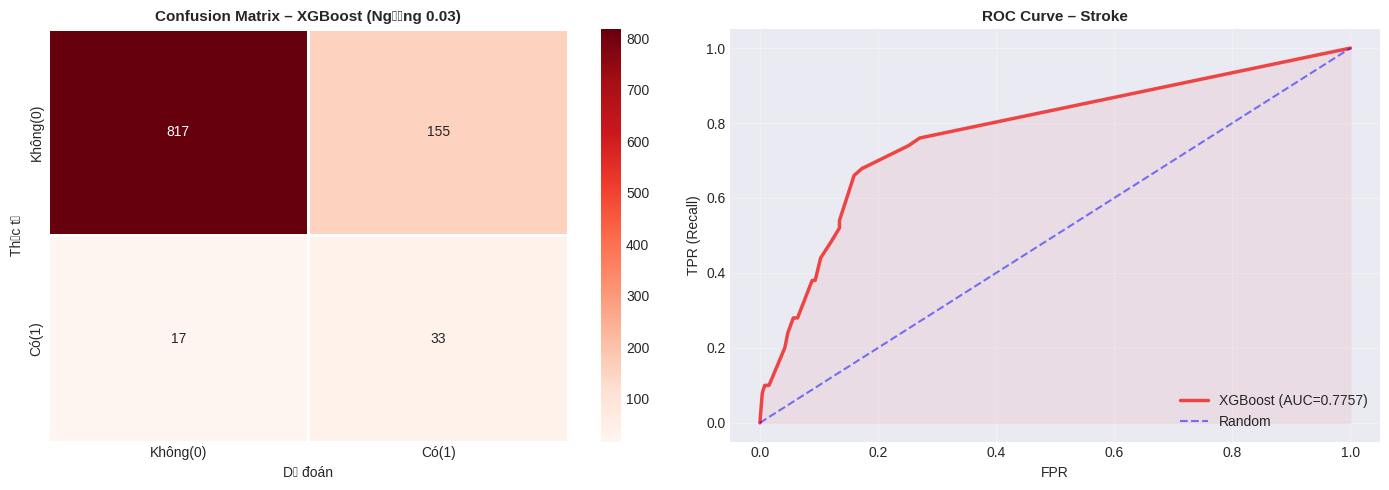

  TP=33 | TN=817 | FP=155 | FN=17

🚀 HUẤN LUYỆN RANDOM FOREST (Baseline)

🏆 XGBoost vs RF – STROKE
  Metric       │ XGBoost  │ RF       │ Winner
  ────────────────────────────────────────────────
  Accuracy     │  0.8317 │  0.9442 │ RF      ✅
  Precision    │  0.1755 │  0.2308 │ RF      ✅
  Recall       │  0.6600 │  0.0600 │ XGBoost ✅
  F1-Score     │  0.2773 │  0.0952 │ XGBoost ✅
  AUC-ROC      │  0.7757 │  0.7894 │ RF      ✅

📊 5-FOLD CV CỦA XGBOOST:
  Accuracy    : 0.9709 ± 0.0041
  Recall      : 0.9481 ± 0.0083
  AUC-ROC     : 0.9926 ± 0.0024


In [9]:
print("🚀 TÌM NGƯỠNG TỐI ƯU Y KHOA (THRESHOLD F2)")
# Dùng xác suất từ mô hình đã hiệu chuẩn (Calibrated Model)
y_prob_xgb = calibrated_xgb.predict_proba(X_test_d)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test_d, y_prob_xgb)
f2_scores = (5*(precisions[:-1]*recalls[:-1]))/(4*precisions[:-1]+recalls[:-1]+1e-8)
best_t_f2 = thresholds[np.argmax(f2_scores)]

joblib.dump({'default':0.5, 'f2_medical':float(best_t_f2)}, f'{DIR_MODELS}/stroke_thresholds.pkl')
print(f"✅ Ngưỡng F2 tối ưu: {best_t_f2:.4f}  → 💾 Đã lưu stroke_thresholds.pkl\n")

# ── BƯỚC ĐÁNH GIÁ (DÙNG NGƯỠNG F2 ĐỂ TĂNG RECALL) ──
y_pred_xgb = (y_prob_xgb >= best_t_f2).astype(int) # Ép dùng ngưỡng F2 thay vì 0.5

acc_xgb  = accuracy_score(y_test_d, y_pred_xgb)
prec_xgb = precision_score(y_test_d, y_pred_xgb)
rec_xgb  = recall_score(y_test_d, y_pred_xgb)
f1_xgb   = f1_score(y_test_d, y_pred_xgb)
auc_xgb  = roc_auc_score(y_test_d, y_prob_xgb)

THRESH = {'Accuracy':0.80,'Precision':0.75,'Recall':0.70,'F1':0.72,'AUC':0.80}
SCORES = {'Accuracy':acc_xgb,'Precision':prec_xgb,'Recall':rec_xgb,'F1':f1_xgb,'AUC':auc_xgb}

print("📊 ĐÁNH GIÁ – STROKE (Theo ngưỡng F2)")
print("="*68)
print(f"  {'Metric':10s} │ {'Score':7s} │ Min   │ Trạng thái")
print("  " + "─"*50)
for name, val in SCORES.items():
    thr = THRESH[name]
    print(f"  {name:10s} │  {val:.4f} │ ≥{thr} │ {'✅ ĐẠT' if val>=thr else '❌ CHƯA ĐẠT'}")
print(f"\n{classification_report(y_test_d, y_pred_xgb, target_names=['Không(0)', 'Có(1)'])}")

# Vẽ CM và ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test_d, y_pred_xgb)
tn,fp,fn,tp = cm.ravel()
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0], xticklabels=['Không(0)','Có(1)'], yticklabels=['Không(0)','Có(1)'], linewidths=1, linecolor='white')
axes[0].set_title(f'Confusion Matrix – XGBoost (Ngưỡng {best_t_f2:.2f})',fontsize=11,weight='bold')
axes[0].set_ylabel('Thực tế'); axes[0].set_xlabel('Dự đoán')

fpr,tpr,_ = roc_curve(y_test_d, y_prob_xgb)
axes[1].plot(fpr,tpr,color='#ef4444',lw=2.5,label=f'XGBoost (AUC={auc_xgb:.4f})')
axes[1].plot([0,1],[0,1],'b--',lw=1.5,alpha=0.5,label='Random')
axes[1].fill_between(fpr,tpr,alpha=0.08,color='#ef4444')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR (Recall)')
axes[1].set_title('ROC Curve – Stroke',fontsize=11,weight='bold')
axes[1].legend(loc='lower right'); axes[1].grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/S04_xgboost_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  TP={tp:,} | TN={tn:,} | FP={fp:,} | FN={fn:,}")

# ── SO SÁNH VỚI RANDOM FOREST ──
print("\n🚀 HUẤN LUYỆN RANDOM FOREST (Baseline)")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5,
    min_samples_leaf=2, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_d, y_train_d)
joblib.dump(rf_model, f'{DIR_MODELS}/stroke_randomforest.pkl')

y_pred_rf = rf_model.predict(X_test_d); y_prob_rf = rf_model.predict_proba(X_test_d)[:,1]
acc_rf, prec_rf, rec_rf = accuracy_score(y_test_d,y_pred_rf), precision_score(y_test_d,y_pred_rf), recall_score(y_test_d,y_pred_rf)
f1_rf, auc_rf = f1_score(y_test_d,y_pred_rf), roc_auc_score(y_test_d,y_prob_rf)

print("\n🏆 XGBoost vs RF – STROKE")
xgb_s = [acc_xgb, prec_xgb, rec_xgb, f1_xgb, auc_xgb]
rf_s  = [acc_rf, prec_rf, rec_rf, f1_rf, auc_rf]
print(f"  {'Metric':12s} │ {'XGBoost':8s} │ {'RF':8s} │ Winner")
print("  " + "─"*48)
metrics_n = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
for n,xv,rv in zip(metrics_n, xgb_s, rf_s):
    print(f"  {n:12s} │  {xv:.4f} │  {rv:.4f} │ {'XGBoost ✅' if xv>=rv else 'RF      ✅'}")

# ── CROSS VALIDATION (Dùng base model chưa hiệu chuẩn để test độ ổn định) ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_res = cross_validate(best_xgb_base, X_train_d, y_train_d,
    cv=cv, scoring={'accuracy':'accuracy','precision':'precision',
                    'recall':'recall','f1':'f1','roc_auc':'roc_auc'}, n_jobs=1)
print("\n📊 5-FOLD CV CỦA XGBOOST:")
for m,k in [('Accuracy','test_accuracy'),('Recall','test_recall'),('AUC-ROC','test_roc_auc')]:
    v=cv_res[k]
    print(f"  {m:12s}: {v.mean():.4f} ± {v.std():.4f}")

---
## 🔍 PHẦN 4: EXPLAINABLE AI VỚI SHAP


---
## 🔍 PHẦN 4: EXPLAINABLE AI VỚI SHAP
---

⏳ SHAP TreeExplainer (Đọc từ Base Estimator)...


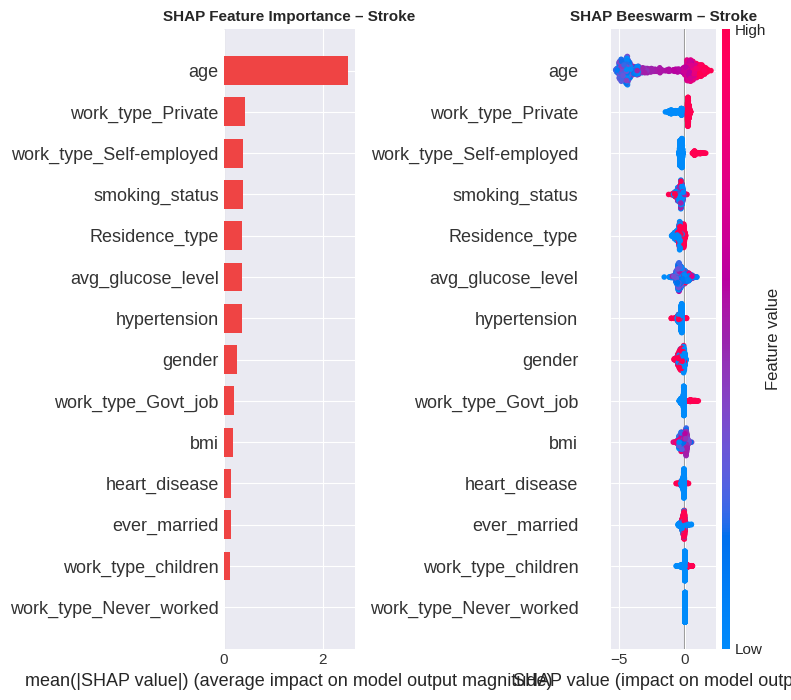

In [10]:
print("---")
print("## 🔍 PHẦN 4: EXPLAINABLE AI VỚI SHAP")
print("---\n")

print("⏳ SHAP TreeExplainer (Đọc từ Base Estimator)...")
# Nạp lại mô hình gốc chưa qua Calibration để SHAP có thể đọc rễ cây
base_xgb = joblib.load(f'{DIR_MODELS}/stroke_xgboost_base.pkl')
explainer = shap.TreeExplainer(base_xgb)

np.random.seed(42)
shap_idx = np.random.choice(len(X_test_d), min(2000, len(X_test_d)), replace=False)
X_shap = X_test_d[shap_idx]

shap_values = explainer.shap_values(X_shap)
joblib.dump(explainer, f'{DIR_MODELS}/stroke_shap_explainer.pkl')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.sca(axes[0])
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_NAMES, plot_type='bar', show=False, color='#ef4444')
axes[0].set_title('SHAP Feature Importance – Stroke',fontsize=11,weight='bold')
plt.sca(axes[1])
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_NAMES, show=False)
axes[1].set_title('SHAP Beeswarm – Stroke',fontsize=11,weight='bold')
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/S06_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


🔴 Nguy cơ CAO  →  Xác suất Đột quỵ: 28.3%  |  High
    #1 Tuổi (năm)                      :   72.0  SHAP=+0.718
    #2 Hút thuốc (0=Ko, 1=Từng, 2=Đang):    2.0  SHAP=-0.536
    #3 work_type_Private               :    0.0  SHAP=-0.419
    #4 Tăng huyết áp (0=Không, 1=Có)   :    1.0  SHAP=-0.299

🟡 Nguy cơ TRUNG BÌNH  →  Xác suất Đột quỵ: 3.7%  |  Medium
    #1 Tăng huyết áp (0=Không, 1=Có)   :    1.0  SHAP=-0.394
    #2 Nơi sống (0=NT, 1=TT)           :    0.0  SHAP=-0.386
    #3 Hút thuốc (0=Ko, 1=Từng, 2=Đang):    1.0  SHAP=-0.329
    #4 Đường huyết (mg/dL)             :  110.0  SHAP=-0.316

🟢 Nguy cơ THẤP  →  Xác suất Đột quỵ: 0.0%  |  Low
    #1 Tuổi (năm)                      :   32.0  SHAP=-4.845
    #2 Giới tính (0=Nữ, 1=Nam)         :    1.0  SHAP=-0.442
    #3 BMI (kg/m²)                     :   22.1  SHAP=-0.420
    #4 Đường huyết (mg/dL)             :   85.0  SHAP=-0.306


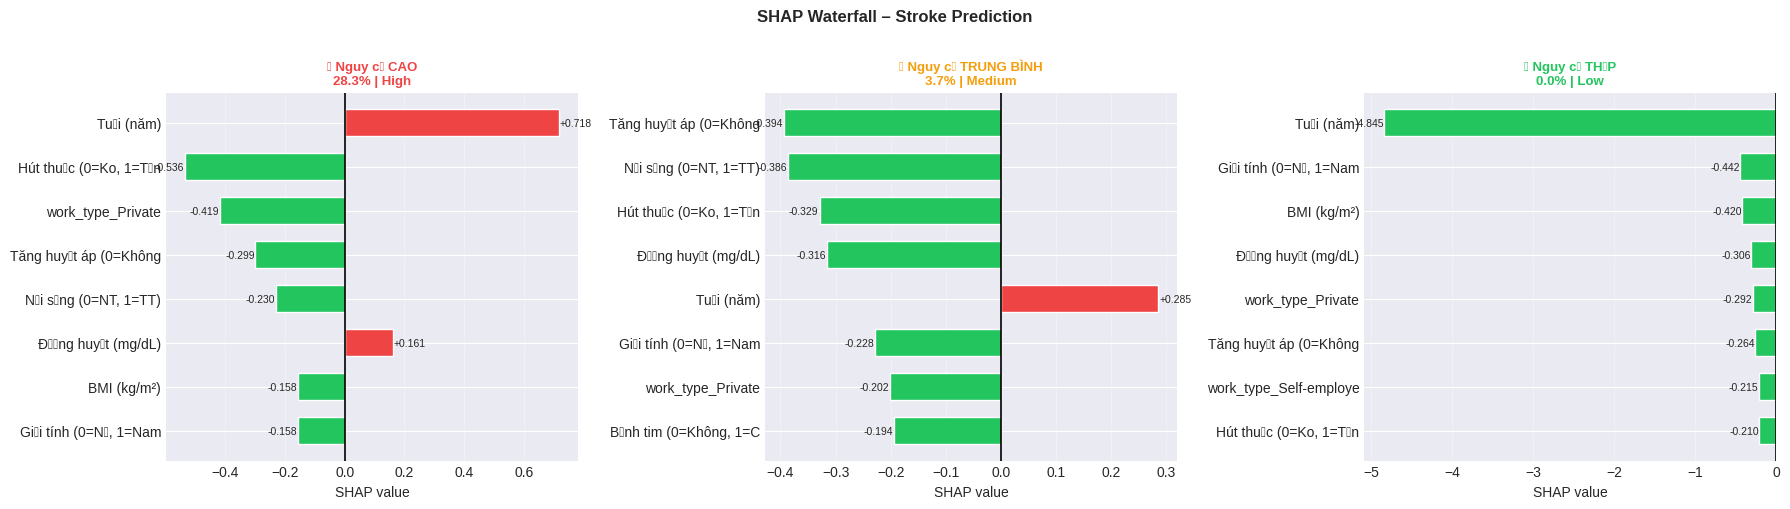

In [11]:
FEATURE_LABELS_S = {
    'gender'           : 'Giới tính (0=Nữ, 1=Nam)',
    'age'              : 'Tuổi (năm)',
    'hypertension'     : 'Tăng huyết áp (0=Không, 1=Có)',
    'heart_disease'    : 'Bệnh tim (0=Không, 1=Có)',
    'ever_married'     : 'Đã kết hôn (0=Không, 1=Có)',
    'work_type'        : 'Công việc (1=Tư, 2=Tự do, 3=NN, 0=Khác)',
    'Residence_type'   : 'Nơi sống (0=NT, 1=TT)',
    'avg_glucose_level': 'Đường huyết (mg/dL)',
    'bmi'              : 'BMI (kg/m²)',
    'smoking_status'   : 'Hút thuốc (0=Ko, 1=Từng, 2=Đang)'
}

def get_shap_explanation_stroke(input_dict):
    model     = joblib.load(f'{DIR_MODELS}/stroke_xgboost.pkl')
    scaler    = joblib.load(f'{DIR_MODELS}/stroke_scaler.pkl')
    features  = joblib.load(f'{DIR_MODELS}/stroke_features.pkl')
    explainer = joblib.load(f'{DIR_MODELS}/stroke_shap_explainer.pkl')
    opt_t     = joblib.load(f'{DIR_MODELS}/stroke_thresholds.pkl').get('f2_medical', 0.5)

    raw = [float(input_dict.get(f, 0)) for f in features]
    X_sc = scaler.transform(np.array(raw).reshape(1,-1))
    sv   = explainer.shap_values(X_sc)[0]
    prob = float(model.predict_proba(X_sc)[0][1])
    risk = 'High' if prob >= opt_t*1.5 else ('Medium' if prob >= opt_t else 'Low')

    feat_list = [{'name':f,'value':round(raw[i],2),
                  'shap_value':round(float(sv[i]),4),
                  'impact':'positive' if sv[i]>0 else 'negative',
                  'label_vn':FEATURE_LABELS_S.get(f,f)}
                 for i,f in enumerate(features)]
    feat_list.sort(key=lambda x: abs(x['shap_value']), reverse=True)
    for r,fea in enumerate(feat_list,1): fea['rank']=r
    return {'base_value':round(float(explainer.expected_value),4),
            'prediction_prob':round(prob,4),'risk_level':risk,
            'optimal_threshold':round(opt_t,4),'features':feat_list}

CASES_STROKE = {
    '🔴 Nguy cơ CAO': {
        'gender':1, 'age':72, 'hypertension':1, 'heart_disease':1, 'ever_married':1,
        'work_type':1, 'Residence_type':1, 'avg_glucose_level':220.5, 'bmi':34.2, 'smoking_status':2
    },
    '🟡 Nguy cơ TRUNG BÌNH': {
        'gender':0, 'age':55, 'hypertension':1, 'heart_disease':0, 'ever_married':1,
        'work_type':2, 'Residence_type':0, 'avg_glucose_level':110.0, 'bmi':27.5, 'smoking_status':1
    },
    '🟢 Nguy cơ THẤP': {
        'gender':1, 'age':32, 'hypertension':0, 'heart_disease':0, 'ever_married':0,
        'work_type':1, 'Residence_type':1, 'avg_glucose_level':85.0, 'bmi':22.1, 'smoking_status':0
    }
}

print("="*70)
all_res_s = []
for cname, cdata in CASES_STROKE.items():
    r = get_shap_explanation_stroke(cdata)
    all_res_s.append((cname, cdata, r))
    print(f"\n{cname}  →  Xác suất Đột quỵ: {r['prediction_prob']*100:.1f}%  |  {r['risk_level']}")
    for feat in r['features'][:4]:
        print(f"    #{feat['rank']} {feat['label_vn']:32s}: {feat['value']:6.1f}  SHAP={feat['shap_value']:+.3f}")

# Vẽ Waterfall
fig, axes = plt.subplots(1,3,figsize=(18,5))
colors_r = {'🔴 Nguy cơ CAO':'#ef4444','🟡 Nguy cơ TRUNG BÌNH':'#f59e0b','🟢 Nguy cơ THẤP':'#22c55e'}
for ax,(cname,_,r) in zip(axes, all_res_s):
    feats = r['features'][:8]
    names = [f['label_vn'][:22] for f in feats]
    svs   = [f['shap_value'] for f in feats]
    bc    = ['#ef4444' if v>0 else '#22c55e' for v in svs]
    ax.barh(names[::-1], svs[::-1], color=bc[::-1], edgecolor='white', height=0.6)
    ax.axvline(x=0, color='black', lw=1.2)
    for i,(n2,val) in enumerate(zip(names[::-1],svs[::-1])):
        ax.text(val+(0.002 if val>=0 else -0.002), i,
                f'{val:+.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=7.5)
    ax.set_title(f"{cname}\n{r['prediction_prob']*100:.1f}% | {r['risk_level']}",
                 fontsize=9.5, weight='bold', color=colors_r[cname])
    ax.set_xlabel('SHAP value'); ax.grid(axis='x', alpha=0.3)
plt.suptitle('SHAP Waterfall – Stroke Prediction',fontsize=12,weight='bold',y=1.01)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/S06_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ TỔNG KẾT


In [12]:
print("="*70); print("📦 ARTIFACTS ĐÃ TẠO – Stroke"); print("="*70)
artifacts = {
    f'{DIR_MODELS}/stroke_xgboost.pkl'       : 'XGBoost (5.1K mẫu)',
    f'{DIR_MODELS}/stroke_shap_explainer.pkl': 'SHAP Explainer',
    f'{DIR_MODELS}/stroke_scaler.pkl'        : 'StandardScaler',
    f'{DIR_MODELS}/stroke_features.pkl'      : f'{len(FEATURE_NAMES)} features',
    f'{DIR_MODELS}/stroke_test_raw.pkl'      : 'Test set raw',
}
import os
for path, desc in artifacts.items():
    ex=os.path.exists(path); sz=os.path.getsize(path)//1024 if ex else 0
    print(f"  {'✅' if ex else '❌'} {desc:45s} [{sz:4d}KB]")

print("\n📊 KẾT QUẢ MÔ HÌNH – Stroke (5.1K)")
print("="*70)
print(f"  Accuracy  : {acc_xgb:.4f}  {'✅' if acc_xgb>=0.80 else '❌'}")
print(f"  Precision : {prec_xgb:.4f}  {'✅' if prec_xgb>=0.75 else '❌'}")
print(f"  Recall    : {rec_xgb:.4f}  {'✅' if rec_xgb>=0.70 else '❌'}")
print(f"  F1-Score  : {f1_xgb:.4f}  {'✅' if f1_xgb>=0.72 else '❌'}")
print(f"  AUC-ROC   : {auc_xgb:.4f}  {'✅' if auc_xgb>=0.80 else '❌'}")
print("="*70)


📦 ARTIFACTS ĐÃ TẠO – Stroke
  ✅ XGBoost (5.1K mẫu)                            [ 704KB]
  ✅ SHAP Explainer                                [2302KB]
  ✅ StandardScaler                                [   1KB]
  ✅ 14 features                                   [   0KB]
  ✅ Test set raw                                  [  94KB]

📊 KẾT QUẢ MÔ HÌNH – Stroke (5.1K)
  Accuracy  : 0.8317  ✅
  Precision : 0.1755  ❌
  Recall    : 0.6600  ❌
  F1-Score  : 0.2773  ❌
  AUC-ROC   : 0.7757  ❌
